# RETO 4: ENTRENAMIENTO Y VALIDACION

In [1]:
# Instalar las librerias y otras cosas que no esta instalada o no tengo en SageMaker
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "-q"])
print("Seaborn instalado correctamente")

Seaborn instalado correctamente


In [2]:
# Importar las librerias necesarias para entrenar datos
import pandas as pd
import boto3
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

print("LIBRERÍAS IMPORTADAS CORRECTAMENTE")

LIBRERÍAS IMPORTADAS CORRECTAMENTE


In [3]:
#Cargar datos desde S3 (PARQUET - CORREGIDO)
# CONFIGURACIÓN S3
s3 = boto3.client('s3')

bucket_name = 'customer-segmentation-lake-purvishpatel'
parquet_path = 'processed/rfm_data/'

# INTENTO 1: lectura directa desde S3
try:
    df = pd.read_parquet(f's3://{bucket_name}/{parquet_path}')
    print("\nDatos cargados correctamente desde S3\n")

except Exception as e:
    print("Error en lectura directa, intentando método alternativo")

    # INTENTO 2: buscar archivo en el bucket
    response = s3.list_objects_v2(
        Bucket=bucket_name,
        Prefix=parquet_path
    )

    parquet_file = None

    if 'Contents' in response:
        for obj in response['Contents']:
            if obj['Key'].endswith('.parquet'):
                parquet_file = obj['Key']
                break

    if parquet_file is None:
        raise Exception("No se encontró ningún archivo .parquet en S3")

    # descargar archivo temporalmente
    local_path = '/tmp/rfm_data.parquet'
    s3.download_file(bucket_name, parquet_file, local_path)

    df = pd.read_parquet(local_path)

    print("\nDatos cargados correctamente desde archivo descargado\n")

# VERIFICACIÓN DEL DATASET
print("Dimensiones del dataset:", df.shape)

print("\nColumnas:")
print(list(df.columns))

print("\nPrimeras filas:")
print(df.head())

print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())


Datos cargados correctamente desde S3

Dimensiones del dataset: (1100, 4)

Columnas:
['CustomerID', 'Recency', 'Frequency', 'MonetaryValue']

Primeras filas:
  CustomerID  Recency  Frequency  MonetaryValue
0      13047       48         17         366.63
1      14688       48         19         444.98
2      16098       48         12         430.60
3      17420       48          7         130.85
4      16250       48         14         226.14

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     1100 non-null   object 
 1   Recency        1100 non-null   int32  
 2   Frequency      1100 non-null   int64  
 3   MonetaryValue  1100 non-null   float64
dtypes: float64(1), int32(1), int64(1), object(1)
memory usage: 30.2+ KB
None

Valores nulos:
CustomerID       0
Recency          0
Frequency        0
MonetaryVa

## Exploración de Datos (BASELINE)

           Recency    Frequency  MonetaryValue
count  1100.000000  1100.000000    1100.000000
mean     26.597273    33.136364     778.119482
std      16.007067    43.610251    1884.449936
min       1.000000     1.000000       0.850000
25%       9.000000    10.000000     206.805000
50%      33.000000    20.000000     346.470000
75%      41.000000    41.250000     692.265000
max      48.000000   672.000000   27834.610000
                Recency  Frequency  MonetaryValue
Recency        1.000000  -0.213851      -0.193983
Frequency     -0.213851   1.000000       0.325802
MonetaryValue -0.193983   0.325802       1.000000


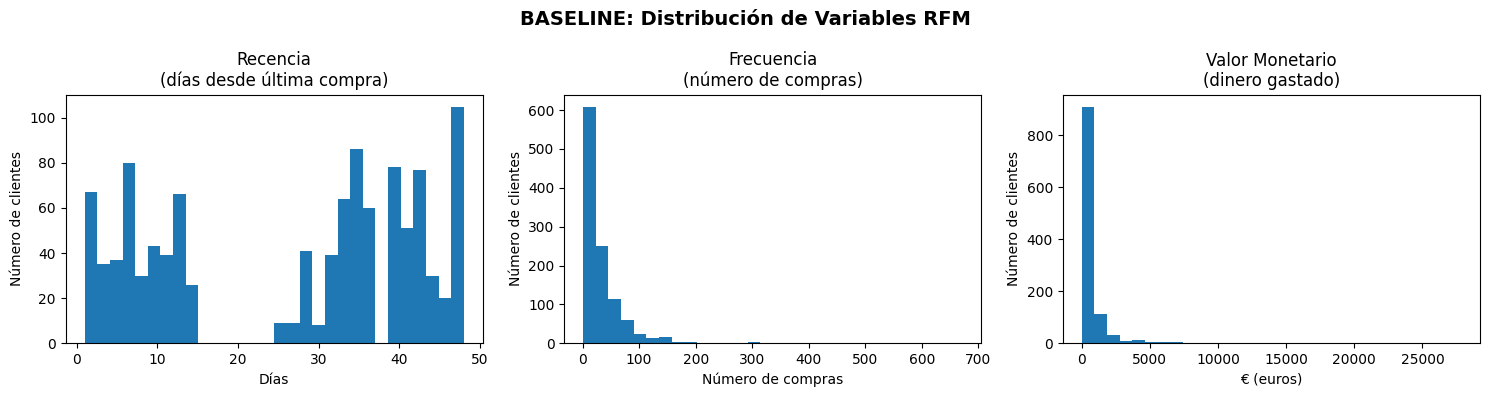

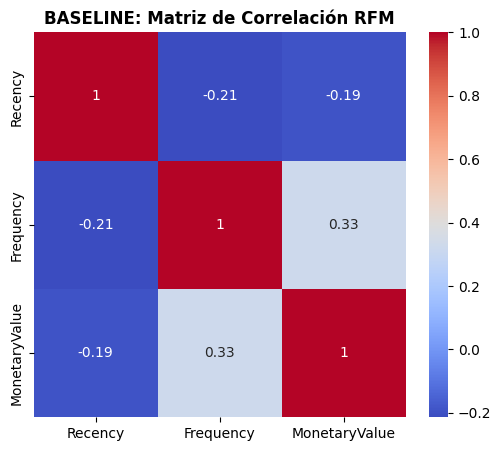

In [4]:
# Selección de variables RFM (solo columnas numéricas necesarias para clustering)
df_numeric = df[['Recency', 'Frequency', 'MonetaryValue']]

# Estadísticas descriptivas básicas del dataset (media, std, min, max, etc.)
print(df_numeric.describe())

# Matriz de correlación para ver relación entre variables RFM
correlation_matrix = df_numeric.corr()
print(correlation_matrix)

# Histogramas para entender la distribución de cada variable antes del modelado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('BASELINE: Distribución de Variables RFM', fontsize=14, fontweight='bold')

axes[0].hist(df['Recency'], bins=30)
axes[0].set_title('Recencia\n(días desde última compra)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Número de clientes')

axes[1].hist(df['Frequency'], bins=30)
axes[1].set_title('Frecuencia\n(número de compras)')
axes[1].set_xlabel('Número de compras')
axes[1].set_ylabel('Número de clientes')

axes[2].hist(df['MonetaryValue'], bins=30)
axes[2].set_title('Valor Monetario\n(dinero gastado)')
axes[2].set_xlabel('€ (euros)')
axes[2].set_ylabel('Número de clientes')

plt.tight_layout()
plt.savefig('01_baseline_distribution.png')
plt.show()

# Heatmap de correlación para visualizar relaciones entre variables RFM
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('BASELINE: Matriz de Correlación RFM', fontweight='bold', fontsize=12)
plt.savefig('02_baseline_correlation.png')
plt.show()
plt.close()

# Este paso sirve como análisis inicial del dataset antes del entrenamiento.
# Permite entender la distribución de los datos y detectar relaciones entre variables.
# Estas visualizaciones se usarán como referencia (baseline) para comparar el modelo final.

## NORMALIZACIÓN DE DATOS


Rangos originales de las variables:
Recency: [1.0, 48.0]
Frequency: [1.0, 672.0]
MonetaryValue: [0.85, 27834.61]

Media después de normalizar:
[-3.22973971e-17  7.42840133e-17 -2.26081780e-17]

Desviación estándar después de normalizar:
[1. 1. 1.]


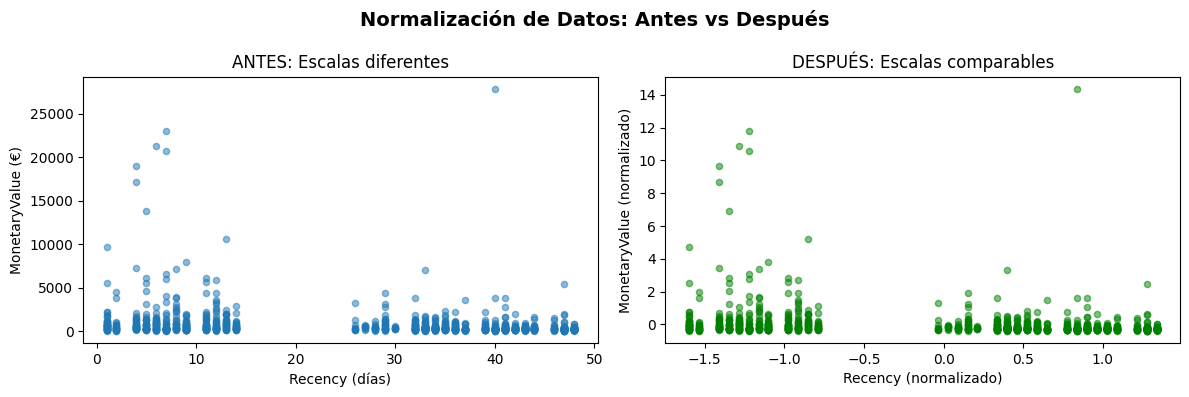

In [5]:
# Selección de variables para clustering (RFM)
X = df[['Recency', 'Frequency', 'MonetaryValue']].values

# ANÁLISIS PREVIO (SIN ESCALAR)
# Se observan los rangos originales para justificar la necesidad de normalización
# K-Means es sensible a la escala porque usa distancias euclidianas

print("\nRangos originales de las variables:")
print("Recency:", [X[:, 0].min(), X[:, 0].max()])
print("Frequency:", [X[:, 1].min(), X[:, 1].max()])
print("MonetaryValue:", [X[:, 2].min(), X[:, 2].max()])

# NORMALIZACIÓN
# StandardScaler transforma los datos para que:
# - Media = 0
# - Desviación estándar = 1
# Esto evita que variables con mayor magnitud dominen el modelo

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# COMPROBACIÓN POST-NORMALIZACIÓN
# Se verifica que todas las variables quedan en escala comparable

print("\nMedia después de normalizar:")
print(X_scaled.mean(axis=0))

print("\nDesviación estándar después de normalizar:")
print(X_scaled.std(axis=0))


# JUSTIFICACIÓN TEÓRICA
# Sin normalización:
# - MonetaryValue domina el clustering (valores hasta 16000)
# - Recency queda subrepresentado
# Con normalización:
# - Todas las variables tienen el mismo peso en el cálculo de distancia
# - Mejora la calidad del clustering

# VISUALIZACIÓN COMPARATIVA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Normalización de Datos: Antes vs Después', fontsize=14, fontweight='bold')

# Antes de escalar
axes[0].scatter(X[:, 0], X[:, 2], s=20, alpha=0.5)
axes[0].set_title('ANTES: Escalas diferentes')
axes[0].set_xlabel('Recency (días)')
axes[0].set_ylabel('MonetaryValue (€)')

# Después de escalar
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 2], s=20, alpha=0.5, color="green")
axes[1].set_title('DESPUÉS: Escalas comparables')
axes[1].set_xlabel('Recency (normalizado)')
axes[1].set_ylabel('MonetaryValue (normalizado)')

plt.tight_layout()
plt.savefig('03_normalization_before_after.png')
plt.show()
plt.close()

## Encontrar número óptimo de clusters (ITERACIÓN 1)

[ITERACIÓN 1] Probar diferentes valores de k (2 a 10)

[ENTRENANDO MÚLTIPLES MODELOS]
k= 2 → Silhouette:  0.5327 | Davies-Bouldin:  0.9125 | Inertia:    2220.80
k= 3 → Silhouette:  0.5615 | Davies-Bouldin:  0.8047 | Inertia:    1359.35
k= 4 → Silhouette:  0.5670 | Davies-Bouldin:  0.6603 | Inertia:     966.71
k= 5 → Silhouette:  0.5770 | Davies-Bouldin:  0.7418 | Inertia:     710.28
k= 6 → Silhouette:  0.5011 | Davies-Bouldin:  0.7886 | Inertia:     598.03
k= 7 → Silhouette:  0.4917 | Davies-Bouldin:  0.8425 | Inertia:     526.72
k= 8 → Silhouette:  0.4418 | Davies-Bouldin:  0.7925 | Inertia:     464.51
k= 9 → Silhouette:  0.4499 | Davies-Bouldin:  0.7508 | Inertia:     418.08
k=10 → Silhouette:  0.4153 | Davies-Bouldin:  0.7928 | Inertia:     359.33

K óptimo encontrado: 5
Mejor Silhouette Score: 0.5770289522268823


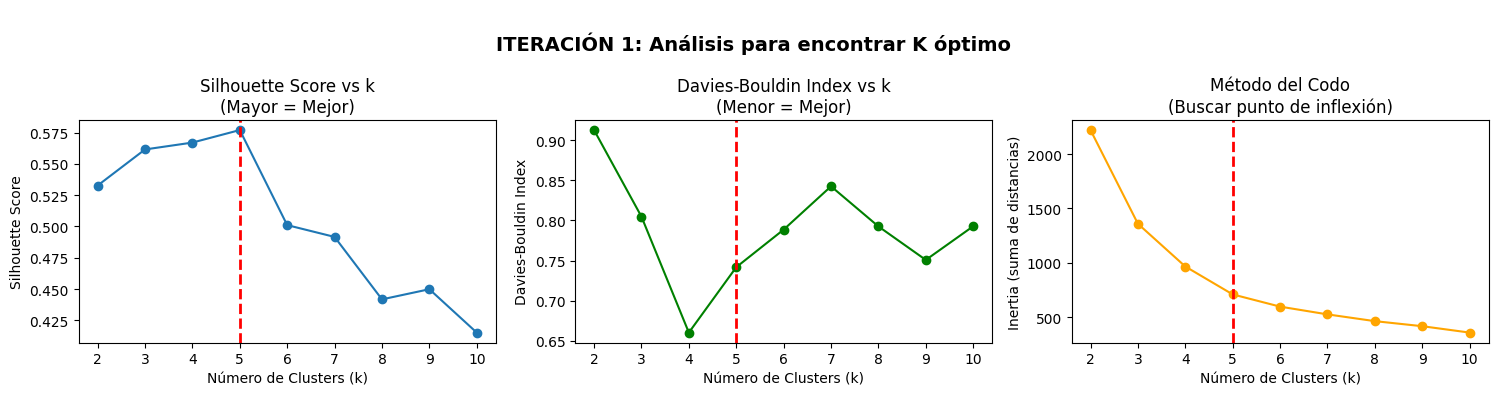

In [6]:
# Rango de valores de K que se van a evaluar
K_range = range(2, 11)

# Listas para almacenar métricas de cada modelo
silhouette_scores = []
davies_bouldin_scores = []
inertias = []

# Mensaje inicial del proceso de búsqueda de K óptimo
print("[ITERACIÓN 1] Probar diferentes valores de k (2 a 10)\n")
print("[ENTRENANDO MÚLTIPLES MODELOS]")

# Entrenamiento de múltiples modelos K-Means con distintos K
for k in K_range:
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10,
        max_iter=300
    )

    # Ajuste del modelo y obtención de clusters
    labels = model.fit_predict(X_scaled)

    # Métrica de cohesión y separación de clusters
    sil = silhouette_score(X_scaled, labels)

    # Métrica de calidad de clustering (menor es mejor)
    db = davies_bouldin_score(X_scaled, labels)

    # Inercia: variabilidad interna de los clusters
    inertia = model.inertia_

    # Guardado de resultados para análisis posterior
    silhouette_scores.append(sil)
    davies_bouldin_scores.append(db)
    inertias.append(inertia)

    # Mostrar resultados por cada valor de K
    print(
        f"k={k:2d} → Silhouette: {sil:7.4f} | "
        f"Davies-Bouldin: {db:7.4f} | Inertia: {inertia:10.2f}"
    )

# Selección del mejor K según Silhouette Score (máxima cohesión)
optimal_k = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

# Visualización de métricas para justificar elección de K
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('\nITERACIÓN 1: Análisis para encontrar K óptimo', fontsize=14, fontweight='bold')

# Resultado final de la iteración
print("\nK óptimo encontrado:", optimal_k)
print("Mejor Silhouette Score:", best_score)

# Gráfico 1: Silhouette Score (mayor es mejor)
axes[0].plot(K_range, silhouette_scores, marker='o')
axes[0].axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Óptimo: k={optimal_k}')
axes[0].set_title('Silhouette Score vs k\n(Mayor = Mejor)')
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Silhouette Score')


# Gráfico 2: Davies-Bouldin Index (menor es mejor)
axes[1].plot(K_range, davies_bouldin_scores, marker='o', color='green')
axes[1].axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Óptimo: k={optimal_k}')
axes[1].set_title('Davies-Bouldin Index vs k\n(Menor = Mejor)')
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Index')

# Gráfico 3: Método del codo (inercia)
axes[2].plot(K_range, inertias, marker='o', color='orange')
axes[2].axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Óptimo: k={optimal_k}')
axes[2].set_title('Método del Codo\n(Buscar punto de inflexión)')
axes[2].set_xlabel('Número de Clusters (k)')
axes[2].set_ylabel('Inertia (suma de distancias)')

plt.tight_layout()
plt.savefig('04_elbow_analysis_iteration1.png')
plt.show()

## ENTRENAMIENTO FINAL DE K-MEANS CON K ÓPTIMO


Resultados del modelo:
Iteraciones hasta convergencia: 8
Inertia final: 710.28
Silhouette Score: 0.577
Davies-Bouldin Index: 0.7418

Distribución de clientes por cluster:
Cluster 0: 109 clientes (9.9%)
Cluster 1: 643 clientes (58.5%)
Cluster 2: 7 clientes (0.6%)
Cluster 3: 8 clientes (0.7%)
Cluster 4: 333 clientes (30.3%)

Varianza explicada por PCA:
PC1: 49.8%
PC2: 27.8%


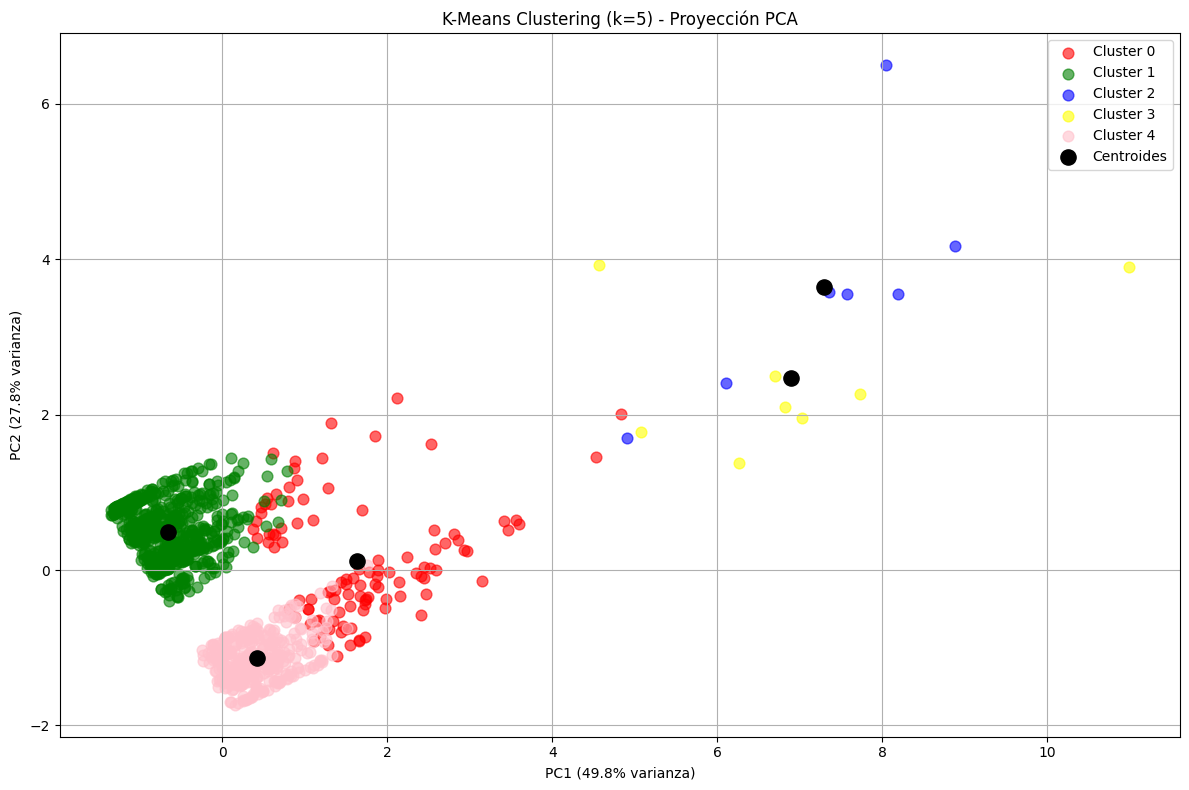

In [12]:
# PASO 7: ENTRENAMIENTO FINAL DE K-MEANS CON K ÓPTIMO
# Definición y entrenamiento del modelo final
kmeans_final = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

# Evaluación del modelo
print("\nResultados del modelo:")
print("Iteraciones hasta convergencia:", kmeans_final.n_iter_)
print("Inertia final:", round(kmeans_final.inertia_, 2))
print("Silhouette Score:", round(silhouette_score(X_scaled, cluster_labels), 4))
print("Davies-Bouldin Index:", round(davies_bouldin_score(X_scaled, cluster_labels), 4))

# Añadir clusters al dataset
df['Cluster'] = cluster_labels

# Distribución de clientes por cluster
print("\nDistribución de clientes por cluster:")
cluster_dist = df['Cluster'].value_counts().sort_index()
for cluster_id, count in cluster_dist.items():
    percentage = (count / len(df)) * 100
    print(f"Cluster {cluster_id}: {count} clientes ({percentage:.1f}%)")

# Reducción de dimensionalidad con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

print("\nVarianza explicada por PCA:")
print(f"PC1: {var1:.1f}%")
print(f"PC2: {var2:.1f}%")

# Visualización de clusters
fig, ax = plt.subplots(figsize=(12, 8))

# Colores más claros y diferenciables
colors = ['red', 'green', 'blue', 'yellow', 'pink']

for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=60
    )

# Centroides como puntos normales (no estrella)
centroides_pca = pca.transform(kmeans_final.cluster_centers_)

ax.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    c='black',
    s=120,
    label='Centroides'
)

# Configuración del gráfico
ax.set_xlabel(f'PC1 ({var1:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({var2:.1f}% varianza)')
ax.set_title(f'K-Means Clustering (k={optimal_k}) - Proyección PCA')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('05_kmeans_clusters_visualization.png')
plt.show()

## Análisis detallado de clusters (VALIDACIÓN CUALITATIVA)


CLUSTER 0 - 109 clientes (9.9%)

RECENCIA (días desde última compra):
Media:       15.7
Mediana:     12.0
Std:         12.1
Rango:    [1, 44]

FRECUENCIA (número de compras):
Media:       98.8
Mediana:     91.0
Std:         33.1
Rango:    [37, 201]

VALOR MONETARIO (gasto total):
Media:    €   1904.48
Mediana:  €   1270.96
Std:      €   1837.91
Rango:    [€208.05, €10573.22]

SEGMENTO IDENTIFICADO:
RECIENTE, FRECUENTE, ALTO VALOR
Segmento: CHAMPIONS

CLUSTER 1 - 643 clientes (58.5%)

RECENCIA (días desde última compra):
Media:       38.8
Mediana:     40.0
Std:          6.0
Rango:    [26, 48]

FRECUENCIA (número de compras):
Media:       22.0
Mediana:     16.0
Std:         18.3
Rango:    [1, 96]

VALOR MONETARIO (gasto total):
Media:    €    401.93
Mediana:  €    300.65
Std:      €    435.43
Rango:    [€12.45, €3834.30]

SEGMENTO IDENTIFICADO:
RECIENTE, FRECUENTE, BAJO VALOR
Segmento: PROMESAS

CLUSTER 2 - 7 clientes (0.6%)

RECENCIA (días desde última compra):
Media:       10.4
Median

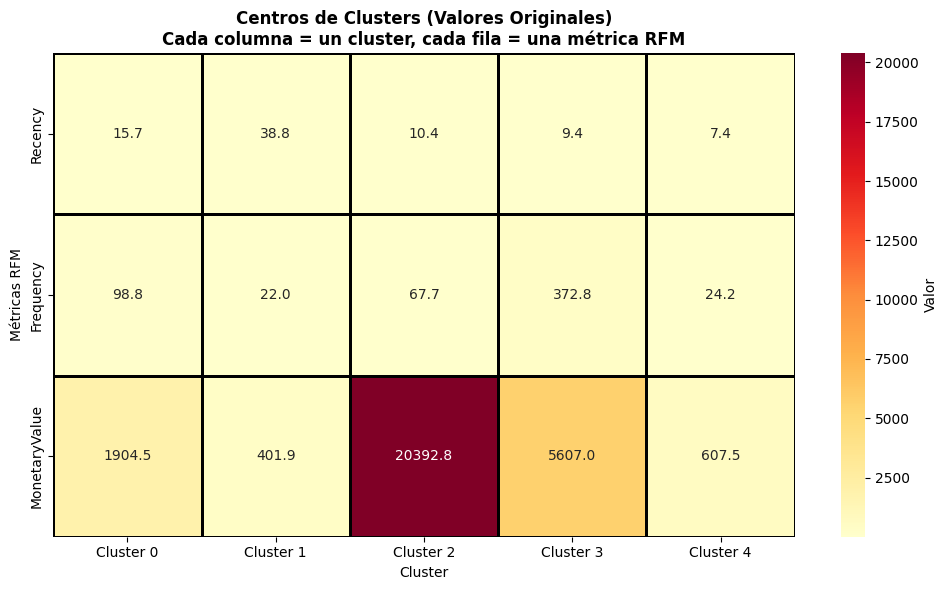


Resumen de clusters:
   Cluster  Clientes  Recency_Media  Frequency_Media  MonetaryValue_Media
0        0       109      15.706422        98.798165          1904.484128
1        1       643      38.768274        22.048212           401.925677
2        2         7      10.428571        67.714286         20392.791429
3        3         8       9.375000       372.750000          5607.047500
4        4       333       7.414414        24.168168           607.503093


In [18]:
# Análisis estadístico de cada cluster en términos de RFM
for cluster in range(optimal_k):
    cluster_mask = df['Cluster'] == cluster
    cluster_data = df[cluster_mask]

    print("\n" + "="*70)
    print(f"CLUSTER {cluster} - {len(cluster_data)} clientes ({len(cluster_data)/len(df)*100:.1f}%)")
    print("="*70)

    # Métricas de Recencia
    print("\nRECENCIA (días desde última compra):")
    print(f"Media:    {cluster_data['Recency'].mean():7.1f}")
    print(f"Mediana:  {cluster_data['Recency'].median():7.1f}")
    print(f"Std:      {cluster_data['Recency'].std():7.1f}")
    print(f"Rango:    [{cluster_data['Recency'].min():.0f}, {cluster_data['Recency'].max():.0f}]")

    # Métricas de Frecuencia
    print("\nFRECUENCIA (número de compras):")
    print(f"Media:    {cluster_data['Frequency'].mean():7.1f}")
    print(f"Mediana:  {cluster_data['Frequency'].median():7.1f}")
    print(f"Std:      {cluster_data['Frequency'].std():7.1f}")
    print(f"Rango:    [{cluster_data['Frequency'].min():.0f}, {cluster_data['Frequency'].max():.0f}]")

    # Métricas Monetarias
    print("\nVALOR MONETARIO (gasto total):")
    print(f"Media:    €{cluster_data['MonetaryValue'].mean():10.2f}")
    print(f"Mediana:  €{cluster_data['MonetaryValue'].median():10.2f}")
    print(f"Std:      €{cluster_data['MonetaryValue'].std():10.2f}")
    print(f"Rango:    [€{cluster_data['MonetaryValue'].min():.2f}, €{cluster_data['MonetaryValue'].max():.2f}]")
    
    # Interpretación de negocio
    rec_level = "RECIENTE" if cluster_data['Recency'].mean() < 50 else "ANTIGUO"
    freq_level = "FRECUENTE" if cluster_data['Frequency'].mean() > 10 else "OCASIONAL"
    val_level = "ALTO VALOR" if cluster_data['MonetaryValue'].mean() > 500 else "BAJO VALOR"

    print("\nSEGMENTO IDENTIFICADO:")
    print(f"{rec_level}, {freq_level}, {val_level}")

    # Asignación de nombre de negocio al cluster
    if rec_level == "RECIENTE" and freq_level == "FRECUENTE" and val_level == "ALTO VALOR":
        segment_name = "CHAMPIONS"
    elif rec_level == "RECIENTE" and freq_level == "FRECUENTE":
        segment_name = "PROMESAS"
    elif rec_level == "ANTIGUO" and val_level == "ALTO VALOR":
        segment_name = "EN RIESGO"
    else:
        segment_name = "OCASIONALES"

    print(f"Segmento: {segment_name}")

# Transformación de centroides a escala original
centers_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centers_df = pd.DataFrame(
    centers_original,
    columns=['Recency', 'Frequency', 'MonetaryValue'],
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

# Heatmap de los centroides
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(centers_df.T, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Valor'}, linewidths=2, linecolor='black', ax=ax)
ax.set_title('Centros de Clusters (Valores Originales)\n' +'Cada columna = un cluster, cada fila = una métrica RFM', fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Métricas RFM')

plt.tight_layout()
plt.savefig('06_cluster_centers_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen para el informe
resumen = []

for cluster in range(optimal_k):
    cluster_mask = df['Cluster'] == cluster
    cluster_data = df[cluster_mask]

    resumen.append([
        cluster,
        len(cluster_data),
        cluster_data['Recency'].mean(),
        cluster_data['Frequency'].mean(),
        cluster_data['MonetaryValue'].mean()
    ])

resumen_df = pd.DataFrame(
    resumen,
    columns=['Cluster', 'Clientes', 'Recency_Media', 'Frequency_Media', 'MonetaryValue_Media']
)

print("\nResumen de clusters:")
print(resumen_df)

## ITERACIÓN 2 - VALIDACIÓN DE ROBUSTEZ DEL MODELO

El modelo con diferentes random_state para comprobar consistencia

Entrenamiento con múltiples semillas
Seed 42: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 123: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 456: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 789: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 999: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 111: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 222: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 333: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 444: Silhouette=0.5770, Davies-Bouldin=0.7418
Seed 555: Silhouette=0.5770, Davies-Bouldin=0.7418

Análisis de estabilidad

Silhouette Score
Media: 0.5770
Desviación estándar: 0.000000
Rango: [0.5770, 0.5770]

Davies-Bouldin Index
Media: 0.7418
Desviación estándar: 0.000000

Conclusión: el modelo es robusto (baja variabilidad)



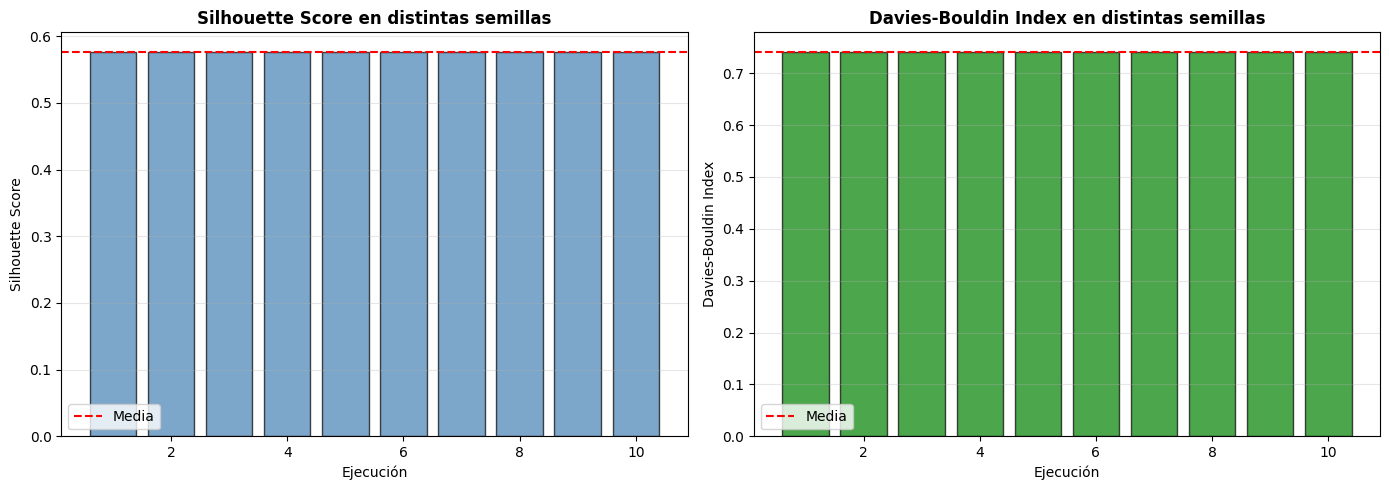

In [24]:
# Objetivo: comprobar si el modelo es estable cambiando la semilla aleatoria
print("El modelo con diferentes random_state para comprobar consistencia")

# Listas para almacenar resultados de cada ejecución
silhouette_iter2 = []
davies_bouldin_iter2 = []
inertia_iter2 = []

# Diferentes semillas para evaluar estabilidad del modelo
seeds = [42, 123, 456, 789, 999, 111, 222, 333, 444, 555]

print("\nEntrenamiento con múltiples semillas")

# Entrenamiento repetido del modelo
for seed in seeds:
    kmeans_iter = KMeans(
        n_clusters=optimal_k,
        init='k-means++',
        random_state=seed,
        n_init=10,
        max_iter=300
    )

    labels_iter = kmeans_iter.fit_predict(X_scaled)

    # Cálculo de métricas de evaluación
    sil = silhouette_score(X_scaled, labels_iter)
    db = davies_bouldin_score(X_scaled, labels_iter)
    inertia = kmeans_iter.inertia_

    silhouette_iter2.append(sil)
    davies_bouldin_iter2.append(db)
    inertia_iter2.append(inertia)

    print(f"Seed {seed}: Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")

# Análisis de estabilidad del modelo
sil_mean = np.mean(silhouette_iter2)
sil_std = np.std(silhouette_iter2)
db_mean = np.mean(davies_bouldin_iter2)
db_std = np.std(davies_bouldin_iter2)

print("\nAnálisis de estabilidad")

print("\nSilhouette Score")
print(f"Media: {sil_mean:.4f}")
print(f"Desviación estándar: {sil_std:.6f}")
print(f"Rango: [{min(silhouette_iter2):.4f}, {max(silhouette_iter2):.4f}]")

print("\nDavies-Bouldin Index")
print(f"Media: {db_mean:.4f}")
print(f"Desviación estándar: {db_std:.6f}")

# Conclusión sobre robustez
if sil_std < 0.01:
    print("\nConclusión: el modelo es robusto (baja variabilidad)\n")
else:
    print("\nConclusión: el modelo tiene variabilidad moderada\n")

# Visualización de estabilidad del modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score por ejecución
axes[0].bar(range(1, 11), silhouette_iter2, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axhline(sil_mean, color='red', linestyle='--', label='Media')
axes[0].set_title('Silhouette Score en distintas semillas',fontweight='bold')
axes[0].set_xlabel('Ejecución')
axes[0].set_ylabel('Silhouette Score')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Davies-Bouldin por ejecución
axes[1].bar(range(1, 11), davies_bouldin_iter2, color='green', edgecolor='black', alpha=0.7)
axes[1].axhline(db_mean, color='red', linestyle='--', label='Media')
axes[1].set_title('Davies-Bouldin Index en distintas semillas',fontweight='bold')
axes[1].set_xlabel('Ejecución')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('07_iteration2_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

## Guardar artefactos en S3

In [25]:
# En este paso se guardan todos los elementos generados (modelo, scaler, PCA, dataset y gráficos)
# tanto de forma local como en Amazon S3 para su uso posterior y trazabilidad del proyecto.

print("\nPASO 10: guardar modelo y artefactos en S3")

# GUARDADO LOCAL DE ARTEFACTOS
print("\nGuardando archivos localmente")

# Guardar el modelo entrenado de K-Means
# Este archivo permite reutilizar el modelo sin necesidad de reentrenar
joblib.dump(kmeans_final, 'kmeans_model.pkl')
print("\nModelo K-Means guardado: kmeans_model.pkl")

# Guardar el scaler utilizado en la normalización de datos
# Es necesario para aplicar exactamente la misma transformación a nuevos datos
joblib.dump(scaler, 'scaler.pkl')
print("\nScaler guardado: scaler.pkl")

# Guardar el modelo PCA utilizado para reducción de dimensionalidad
# Permite reproducir las visualizaciones y transformaciones 2D
joblib.dump(pca, 'pca_model.pkl')
print("\nModelo PCA guardado: pca_model.pkl")

# Guardar el dataset final con la columna de clusters asignados
# Este archivo representa el resultado final del análisis de segmentación
df.to_csv('customer_segments_final.csv', index=False)
print("\nDataset con clusters guardado: customer_segments_final.csv")

# SUBIDA A AMAZON S3
print("\nSubiendo archivos a S3")

try:
    # Subida del modelo K-Means a S3
    # Se almacena en la carpeta models para su uso en producción
    s3.upload_file(
        'kmeans_model.pkl',
        bucket_name,
        'output/models/kmeans_final_model.pkl'
    )
    print("\nModelo subido a S3")

    # Subida del scaler para mantener consistencia en futuras predicciones
    s3.upload_file(
        'scaler.pkl',
        bucket_name,
        'output/models/scaler_final.pkl'
    )
    print("\nScaler subido a S3")

    # Subida del modelo PCA para reutilización en visualización o transformación
    s3.upload_file(
        'pca_model.pkl',
        bucket_name,
        'output/models/pca_final.pkl'
    )
    print("\nPCA subido a S3")

    # Subida del dataset final con clusters asignados
    # Este archivo contiene el resultado final del proyecto de segmentación
    s3.upload_file(
        'customer_segments_final.csv',
        bucket_name,
        'output/results/customer_segments_final.csv'
    )
    print("\nDataset final subido a S3")

    # SUBIDA DE VISUALIZACIONES
    # Lista de gráficos generados durante todo el proyecto
    # Se suben para incluirlos en el informe final
    files = [
        '01_baseline_distribution.png',
        '02_baseline_correlation.png',
        '03_normalization_before_after.png',
        '04_elbow_analysis_iteration1.png',
        '05_kmeans_clusters_visualization.png',
        '06_cluster_centers_heatmap.png',
        '07_iteration2_robustness.png'
    ]

    # Subida iterativa de cada gráfico a S3
    for filename in files:
        try:
            s3.upload_file(
                filename,
                bucket_name,
                f'output/visualizations/{filename}'
            )
            print("\nArchivo subido:", filename)
        except FileNotFoundError:
            # Si algún gráfico no existe, se continúa sin detener el proceso
            print("\nArchivo no encontrado:", filename)

except Exception as e:
    # Captura de errores en caso de fallo en la subida a S3
    print("\nError al subir archivos:", str(e))

# RESUMEN FINAL DE UBICACIONES
print("\nPASO 10 completado: artefactos almacenados en S3")

print("\nResumen de rutas en S3")

print("\nModels:")
print(f"s3://{bucket_name}/output/models/kmeans_final_model.pkl")
print(f"s3://{bucket_name}/output/models/scaler_final.pkl")
print(f"s3://{bucket_name}/output/models/pca_final.pkl")

print("\nResults:")
print(f"s3://{bucket_name}/output/results/customer_segments_final.csv")

print("\nVisualizations:")
print(f"s3://{bucket_name}/output/visualizations/")


PASO 10: guardar modelo y artefactos en S3

Guardando archivos localmente

Modelo K-Means guardado: kmeans_model.pkl

Scaler guardado: scaler.pkl

Modelo PCA guardado: pca_model.pkl

Dataset con clusters guardado: customer_segments_final.csv

Subiendo archivos a S3

Modelo subido a S3

Scaler subido a S3

PCA subido a S3

Dataset final subido a S3

Archivo subido: 01_baseline_distribution.png

Archivo subido: 02_baseline_correlation.png

Archivo subido: 03_normalization_before_after.png

Archivo subido: 04_elbow_analysis_iteration1.png

Archivo subido: 05_kmeans_clusters_visualization.png

Archivo subido: 06_cluster_centers_heatmap.png

Archivo subido: 07_iteration2_robustness.png

PASO 10 completado: artefactos almacenados en S3

Resumen de rutas en S3

Models:
s3://customer-segmentation-lake-purvishpatel/output/models/kmeans_final_model.pkl
s3://customer-segmentation-lake-purvishpatel/output/models/scaler_final.pkl
s3://customer-segmentation-lake-purvishpatel/output/models/pca_final